In [99]:
import pandas as pd
import numpy as np
from coffea.util import load
import outvars # Assuming this is a local module you have
import mplhep as hep
import matplotlib.pyplot as plt
import awkward as ak
from sklearn.metrics import roc_curve, auc

# Set CMS style for all plots
hep.style.use("CMS")

In [3]:
def dnn_cut(df_):
    """Base kinematic and score cuts for the DNN region."""
    base_cuts = (
        (df_['n_b_outZH'] == 2) &
        #(df_['ZH_bbvLscore'] >= 0.9105) &
        (df_['n_ak4jets']   >= 5)       &
        (df_['ZH_pt']       >= 200)     &
        (df_['MET_pt']      >= 20)      &
        (df_['ZH_M']        >= 50)      &
        (df_['ZH_M']        <= 200)
    )
    return base_cuts

def plot_cut(df_):
    """Additional cuts specifically for the plotting region."""
    return (df_['ZH_pt'] > 200)

In [110]:
class TaggerEvaluator:
    """ Evaluates and plots signal vs background for fatjet taggers """
    
    # ---------------------------------------------------------
    # Define Variable Categories (Tells parser which dict key to use)
    # ---------------------------------------------------------
    spanet_vars = ['ttzbb', 'tthbb', 'ttbb', 'ttlf', 'ttcc', 'signal']
    
    # Add your FatJet variables here (e.g., 'pt' becomes 'FatJetSorted_pt')
    fatjet_vars = ['pt', 'eta', 'phi', 'msoftdrop', 'particleNetLegacy_Xbb', 'DeepAK8_score', 'particleNetLegacy_QCD', 'particleNetLegacy_Xbb', 'particleNet_XbbVsQCD', 'particleNetLegacy_Xqq', 'globalParT3_Xbb', 'globalParT3_Xqq', 'globalParT3_QCD'] 

    def __init__(self, filein, tagger_var='signal', output_name="tagger_plot"):
        self.filein = filein
        self.tagger_var = tagger_var
        self.output_name = output_name
        self.genmatchreq = 'matchedGen_ZHbb_bb'
        
        # Load variable lists from your outvars module
        self.sig_vars = outvars.common_vars + outvars.sig_vars + outvars.weight_vars + ['particleNetLegacy_QCD', 'particleNetLegacy_Xbb', 'particleNet_XbbVsQCD', 'particleNetLegacy_Xqq', 'globalParT3_Xbb', 'globalParT3_Xqq', 'globalParT3_QCD']
        self.bkg_vars = outvars.common_vars + outvars.bkg_vars + outvars.weight_vars + ['particleNetLegacy_QCD', 'particleNetLegacy_Xbb', 'particleNet_XbbVsQCD', 'particleNetLegacy_Xqq', 'globalParT3_Xbb', 'globalParT3_Xqq', 'globalParT3_QCD']

        if self.tagger_var in ['particleNetLegacy_XbbVsQCD', 'particleNetLegacy_XbbVsQCDandLF', 'globalParT3_XbbVsQCD', 'globalParT3_XbbVsQCDandLF']  and self.tagger_var not in self.fatjet_vars:
            self.fatjet_vars.append(self.tagger_var)
            
        # FORCE the tagger to be extracted
        if self.tagger_var not in self.sig_vars:
            self.sig_vars.append(self.tagger_var)
        if self.tagger_var not in self.bkg_vars:
            self.bkg_vars.append(self.tagger_var)
        # Define signal and background categories
        self.sig_procs = ['ttHTobb__genMatch', 'ttHToNonbb__genMatch', 'TTZToQQ__genMatch']
        self.bkg_procs = [
            "TTbb_Hadronic__tt+B", "TTbb_SemiLeptonic__tt+B", "TTbb_2L2Nu__tt+B",
            "TTToSemiLeptonic__tt+LF", "TTToSemiLeptonic__tt+C", "TTTo2L2Nu__tt+LF",
            "TTTo2L2Nu__tt+C", "TTToHadronic__tt+LF", "TTToHadronic__tt+C"
        ]
        
        self.label_dict = {
            "TTBar": r'$\mathsf{t\bar{t}+\text{LF}}$, $\mathsf{t\bar{t}+c\bar{c}}$',
            "tt_B": r'$\mathsf{t\bar{t}+b\bar{b}}$',
            "VJets": r'$\mathsf{V+jets}$',
            "QCD": r'$\mathsf{QCD}$',
            "old_ttZbb": r'$\mathsf{t\bar{t}Z}$',
            "ttH": r'$\mathsf{t\bar{t}H}$'
        }

        # 1. Load and prepare DataFrames
        self.s_df, self.b_df = self.get_sigbkg()
        self.sb_df = pd.concat([self.s_df, self.b_df], ignore_index=True)
        
        # 2. Apply cuts once
        cuts = dnn_cut(self.sb_df) & plot_cut(self.sb_df)
        self.sb_df = self.sb_df[cuts].copy()
        print(self.sb_df.keys())
        
        # 3. Compute final plot weight
        # Weight = topptWeight * norm_weight * sign(genWeight)
        self.sb_df['final_weight'] = (
            self.sb_df['topptWeight'] * self.sb_df['norm_weight'] * np.sign(self.sb_df['genWeight'])
        )

        # 4. Setup Binning (Adjust range and bin count as needed!)
        self.bins = np.linspace(0, 1, 100) 


    def _extract_process_data(self, base_dict, var_list, genweight, norm_multiplier=1.0):
        """ Helper method to efficiently extract and format a single dictionary of arrays. """
        tmp_data = {}
        
        # 1. Grab the counts for unflattening FatJet variables
        try:
            fatjet_counts = base_dict['FatJetSorted_N'].value
        except KeyError:
            fatjet_counts = None
            print("Warning: 'FatJetSorted_N' not found. FatJets cannot be unflattened.")
            
        if 'FatJetSorted_particleNetLegacy_Xbb' in base_dict and 'FatJetSorted_particleNetLegacy_QCD' in base_dict:
            # Element-wise math works perfectly here!
            xbb = base_dict['FatJetSorted_particleNetLegacy_Xbb'].value
            xqq = base_dict['FatJetSorted_particleNetLegacy_Xqq'].value
            qcd = base_dict['FatJetSorted_particleNetLegacy_QCD'].value
            gpt_xbb = base_dict['FatJetSorted_globalParT3_Xbb'].value
            gpt_xqq = base_dict['FatJetSorted_globalParT3_Xqq'].value
            gpt_qcd = base_dict['FatJetSorted_globalParT3_QCD'].value
            
            # Avoid division by zero
            denom = xbb + qcd + xqq
            custom_disc = ak.where(denom > 0, xbb / denom, 0)
            custom_disc1 = ak.where(denom > 0, xbb /(xbb + qcd), 0)
            custom_disc2 = ak.where((gpt_xbb + gpt_qcd) > 0, gpt_xbb /(gpt_xbb + gpt_qcd), 0)
            custom_disc3 = ak.where((gpt_xbb + gpt_qcd + gpt_xqq) > 0, gpt_xbb /(gpt_xbb + gpt_qcd + gpt_xqq), 0)
            # Store it back in the dictionary so the rest of the function processes it normally
            base_dict['FatJetSorted_particleNetLegacy_XbbVsQCD'] = custom_disc1
            base_dict['FatJetSorted_particleNetLegacy_XbbVsQCDandLF'] = custom_disc
            base_dict['FatJetSorted_globalParT3_XbbVsQCD'] = custom_disc2
            base_dict['FatJetSorted_globalParT3_XbbVsQCDandLF'] = custom_disc3

        # 2. Calculate the sorting indices based on the CURRENT tagger score
        sort_indices = None
        if self.tagger_var in self.fatjet_vars and fatjet_counts is not None:
            tagger_key = f'FatJetSorted_{self.tagger_var}'
            if tagger_key in base_dict:
                
                # FIX 2: Handle both Coffea accumulators (has .value) and raw Awkward arrays
                raw_tagger_array = base_dict[tagger_key].value if hasattr(base_dict[tagger_key], 'value') else base_dict[tagger_key]
                
                jagged_tagger = ak.unflatten(raw_tagger_array, fatjet_counts)
                sort_indices = ak.argsort(jagged_tagger, axis=1, ascending=False)

        # 3. Process all variables
        for var in var_list:
            if var in self.spanet_vars:
                key = f'spanet_output_{var}'
            elif var in self.fatjet_vars:
                key = f'FatJetSorted_{var}'
            else:
                key = f'events_{var}'

            if key not in base_dict:
                continue

            val = base_dict[key].value if hasattr(base_dict[key], 'value') else base_dict[key]

            if var == 'norm_weight':
                tmp_data[var] = (np.array(val) / genweight) * norm_multiplier
                
            elif var in self.fatjet_vars:
                if fatjet_counts is not None:
                    # Unflatten the array
                    jagged_val = ak.unflatten(val, fatjet_counts)
                    
                    # Apply the sort_indices! This sorts pt, eta, phi, AND the scores 
                    # so that the highest-scoring jet is always at index 0.
                    if sort_indices is not None:
                        jagged_val = jagged_val[sort_indices]
                        
                    tmp_data[var] = ak.to_list(jagged_val)
                else:
                    tmp_data[var] = ak.to_list(val) if isinstance(val, ak.Array) else list(val)
                    
            else:
                tmp_data[var] = val
                
        return pd.DataFrame(tmp_data)

    def get_sigbkg(self):
        genweight_df = pd.DataFrame.from_dict(self.filein['sum_signOf_genweights'], orient='index')

        # --- 1. Build Signal DataFrame ---
        sig_dfList = []
        for i in self.sig_procs:
            if i not in self.filein['columns']: continue
            for j in self.filein['columns'][f'{i}'].keys():
                genweight = genweight_df[0][f'{j}']
                base_dict = self.filein['columns'][f'{i}'][f'{j}']['btag_mask']['nominal']
                
                df = self._extract_process_data(base_dict, self.sig_vars + [self.genmatchreq], genweight, 1.0)
                sig_dfList.append(df)
                
        s_df = pd.concat(sig_dfList, ignore_index=True) if sig_dfList else pd.DataFrame()

        # --- 2. Build Background DataFrame ---
        ttbb_xsecs = {
            "TTbb_SemiLeptonic__tt+B": 17.36875,
            "TTbb_2L2Nu__tt+B": 3.74766,
            "TTbb_Hadronic__tt+B": 19.15297
        }
        lumi_pb = 109.95 * 1000

        bkg_dfList = []
        for i in self.bkg_procs:
            if i not in self.filein['columns']: continue
            for j in self.filein['columns'][f'{i}'].keys():
                genweight = genweight_df[0][f'{j}']
                base_dict = self.filein['columns'][f'{i}'][f'{j}']['btag_mask']['nominal']
                
                norm_multiplier = ttbb_xsecs[i] * lumi_pb if i in ttbb_xsecs else 1.0

                df = self._extract_process_data(base_dict, self.bkg_vars, genweight, norm_multiplier)
                
                # Assign match req as false for backgrounds
                df[self.genmatchreq] = False 
                bkg_dfList.append(df)
                
        b_df = pd.concat(bkg_dfList, ignore_index=True) if bkg_dfList else pd.DataFrame()

        # --- 3. Clean up Background Processes ---
        if not b_df.empty:
            # Consolidate labels
            b_df.loc[b_df['process'].str.contains('TTTo'), 'process'] = 'TTBar'
            b_df.loc[b_df['process'].str.contains('TTbb'), 'process'] = 'tt_B'
            
            rename_map = {'QCD_HT': 'QCD', 'WJetsToLNu_HT': 'VJets', 'DYJetsToLL_HT': 'VJets'}
            b_df['process'] = b_df['process'].replace(rename_map)

            allowed_bkgs = ['TTBar', 'tt_B', 'QCD', 'VJets']
            b_df = b_df[b_df['process'].isin(allowed_bkgs)]

        return s_df, b_df
        
    def get_roc_data(self):
        """ Calculates ROC curve data using proper event weights """
        # 1. Get the tagger scores (same logic as your plot_tagger method)
        if self.tagger_var in self.fatjet_vars:
            y_score = self.sb_df[self.tagger_var].str[0].fillna(0)
        else:
            y_score = self.sb_df[self.tagger_var].fillna(0)

        # 2. Define True/False labels (Signal is True, Background is False)
        # Your genmatchreq is already a boolean perfect for this!
        y_true = self.sb_df[self.genmatchreq].astype(int) 

        # 3. Get the weights (take absolute value to avoid negative weight issues in sklearn)
        weights = np.abs(self.sb_df['final_weight'])

        # 4. Calculate standard ROC
        fpr, tpr, thresholds = roc_curve(y_true, y_score, sample_weight=weights)
        roc_auc = auc(fpr, tpr)

        # 5. Convert False Positive Rate to Background Rejection (1 / FPR)
        # Ignore divide-by-zero warnings for the first point where FPR=0
        with np.errstate(divide='ignore'):
            bkg_rejection = np.where(fpr > 0, 1.0 / fpr, 0)

        return tpr, bkg_rejection, roc_auc

    def plot_tagger(self):
        fig, (ax, ax_ratio) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
        fig.set_size_inches(6, 6) 

        bkg_groups = ['TTBar', 'tt_B', 'VJets', 'QCD']
        sig_groups = ['ttH', 'old_ttZbb']

        # --- Evaluate Target Variable ---
        # If the tagger variable is an awkward array (like a FatJet pt), it's stored as a list.
        # For plotting, we assume we want to plot the score of the LEADING FatJet (index 0).
        print(self.sb_df.keys())
        if self.tagger_var in self.fatjet_vars:
            plot_var = self.sb_df[self.tagger_var].str[0] # Grab the 0th element of the list
        else:
            plot_var = self.sb_df[self.tagger_var]

        # --- 1. PREPARE BACKGROUNDS (STACKED) ---
        bkg_hists = []
        bkg_labels = []
        bkg_total_counts = np.zeros(len(self.bins) - 1)

        for proc in bkg_groups:
            mask = (self.sb_df['process'] == proc) & (self.sb_df[self.genmatchreq] == False)
            if not mask.any(): continue
            
            # Use np.histogram to safely bin the weighted data
            counts, _ = np.histogram(plot_var[mask].dropna(), bins=self.bins, weights=self.sb_df.loc[mask, 'final_weight'].dropna())
            bkg_hists.append(counts)
            bkg_labels.append(self.label_dict.get(proc, proc))
            bkg_total_counts += counts

        if bkg_hists:
            hep.histplot(bkg_hists, self.bins, stack=True, histtype='fill', 
                         label=bkg_labels, edgecolor='black', ax=ax)

        # --- 2. PREPARE SIGNALS (STEP) ---
        sig_total_counts = np.zeros(len(self.bins) - 1)
        
        for proc in sig_groups:
            mask = (self.sb_df['process'] == proc) & (self.sb_df[self.genmatchreq] == True)
            if not mask.any(): continue
            
            counts, _ = np.histogram(plot_var[mask].dropna(), bins=self.bins, weights=self.sb_df.loc[mask, 'final_weight'].dropna())
            sig_total_counts += counts
            
            hep.histplot(counts, self.bins, stack=False, histtype='step', linewidth=2,
                         label=self.label_dict.get(proc, proc) + r" (Matched)", ax=ax)

        # --- 3. S/sqrt(B) RATIO PANEL ---
        bin_centers = (self.bins[1:] + self.bins[:-1]) / 2
        bin_widths = (self.bins[1:] - self.bins[:-1]) / 2
        
        with np.errstate(divide='ignore', invalid='ignore'):
            s_over_sqrt_b = np.where(bkg_total_counts > 0, sig_total_counts / np.sqrt(bkg_total_counts), 0)

        ax_ratio.errorbar(x=bin_centers, y=s_over_sqrt_b, xerr=bin_widths, 
                          fmt='o', color='k', label=r'S/$\sqrt{\mathrm{B}}$')
        
        # --- 4. STYLING ---
        ax.set_yscale('log')
        #ax.set_xlim([self.bins[0], self.bins[-1]])
        ax.set_xlim(0.5, 1.0)
        ax.set_ylabel("Events")
        
        ax_ratio.set_ylabel(r'$\mathrm{S/}\sqrt{\mathrm{B}}$', fontsize=12)
        
        # Make the X-label nice
        x_label_name = self.tagger_var if self.tagger_var not in self.fatjet_vars else f"Leading FatJet {self.tagger_var}"
        ax_ratio.set_xlabel(x_label_name, fontsize=12)
        ax_ratio.grid(True, linestyle='--', alpha=0.5)

        ax.legend(loc='upper right', framealpha=0, ncol=2, fontsize=10)
        hep.cms.label(exp="CMS", label="Private Work (Simulation)", loc=0, ax=ax, data=True, rlabel='(13.6 TeV)', fontsize= 16)

        plt.subplots_adjust(hspace=0.05)
        plt.show()

Loading data from: DiscriminatorTest/output_all.coffea
Generating plot for: globalParT3_XbbVsQCDandLF...
Index(['process', 'ZH_pt', 'MET_pt', 'ZH_M', 'n_ak4jets', 'n_b_outZH',
       'ZH_bbvLscore', 'ZH_rap', 'Zbb', 'Hbb', 'Hnonbb', 'Zqq', 'Zllnunu',
       'matchedGenZH', 'matchedGen_Zbb', 'matchedGen_Hbb', 'matchedGen_ZHbb',
       'matchedGen_Zqq', 'matchedGen_ZHbb_bb', 'matchedGen_ZHbb_b',
       'matchedGen_ZHbb_nob', 'genZHpt', 'genWeight', 'norm_weight',
       'topptWeight', 'topptWeight_Up', 'topptWeight_Down',
       'particleNetLegacy_QCD', 'particleNetLegacy_Xbb',
       'particleNet_XbbVsQCD', 'particleNetLegacy_Xqq', 'globalParT3_Xbb',
       'globalParT3_Xqq', 'globalParT3_QCD', 'globalParT3_XbbVsQCDandLF',
       'tt_B'],
      dtype='object')
Index(['process', 'ZH_pt', 'MET_pt', 'ZH_M', 'n_ak4jets', 'n_b_outZH',
       'ZH_bbvLscore', 'ZH_rap', 'Zbb', 'Hbb', 'Hnonbb', 'Zqq', 'Zllnunu',
       'matchedGenZH', 'matchedGen_Zbb', 'matchedGen_Hbb', 'matchedGen_ZHbb',
      

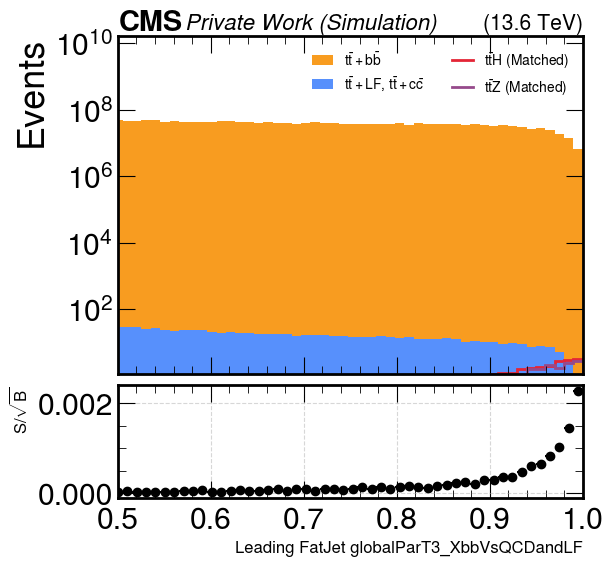

In [113]:
# 1. Define your input file here
coffea_file_path = "DiscriminatorTest/output_all.coffea" 
print(f"Loading data from: {coffea_file_path}")

# Load the file just once
filein = load(coffea_file_path)

# 2. Define the taggers you want to compare
taggers_to_test = ['globalParT3_XbbVsQCDandLF'] 

# 3. Loop through and plot!
for tagger in taggers_to_test:
    print(f"Generating plot for: {tagger}...")
    
    # Initialize the evaluator for this specific tagger
    evaluator = TaggerEvaluator(filein, tagger_var=tagger)
    
    # Draw the plot inline
    evaluator.plot_tagger()

Loading data from: DiscriminatorTest/output_all.coffea
Index(['process', 'ZH_pt', 'MET_pt', 'ZH_M', 'n_ak4jets', 'n_b_outZH',
       'ZH_bbvLscore', 'ZH_rap', 'Zbb', 'Hbb', 'Hnonbb', 'Zqq', 'Zllnunu',
       'matchedGenZH', 'matchedGen_Zbb', 'matchedGen_Hbb', 'matchedGen_ZHbb',
       'matchedGen_Zqq', 'matchedGen_ZHbb_bb', 'matchedGen_ZHbb_b',
       'matchedGen_ZHbb_nob', 'genZHpt', 'genWeight', 'norm_weight',
       'topptWeight', 'topptWeight_Up', 'topptWeight_Down',
       'particleNetLegacy_QCD', 'particleNetLegacy_Xbb',
       'particleNet_XbbVsQCD', 'particleNetLegacy_Xqq', 'globalParT3_Xbb',
       'globalParT3_Xqq', 'globalParT3_QCD', 'particleNetLegacy_XbbVsQCD',
       'tt_B'],
      dtype='object')
Index(['process', 'ZH_pt', 'MET_pt', 'ZH_M', 'n_ak4jets', 'n_b_outZH',
       'ZH_bbvLscore', 'ZH_rap', 'Zbb', 'Hbb', 'Hnonbb', 'Zqq', 'Zllnunu',
       'matchedGenZH', 'matchedGen_Zbb', 'matchedGen_Hbb', 'matchedGen_ZHbb',
       'matchedGen_Zqq', 'matchedGen_ZHbb_bb', 'matched

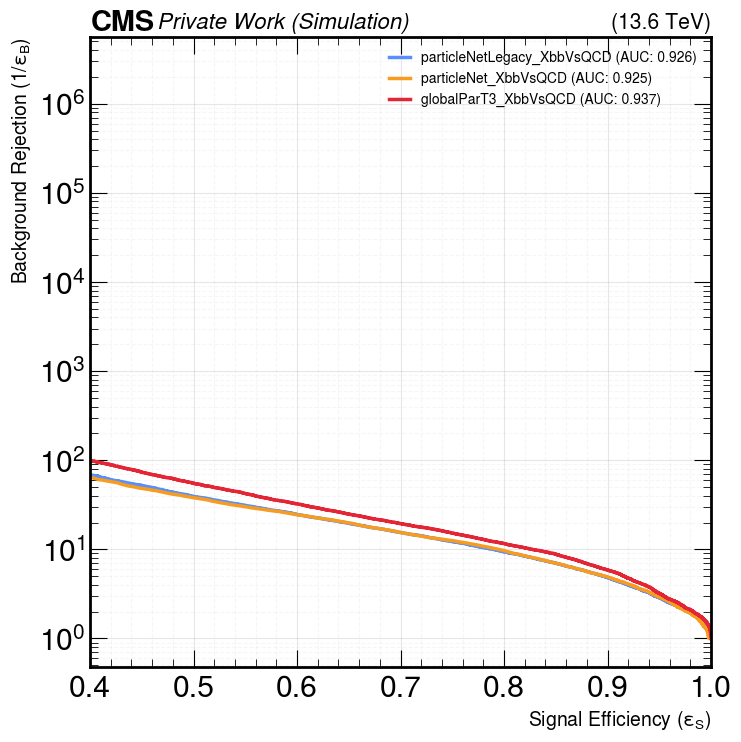

In [116]:
# 1. Define your input file here
coffea_file_path = "DiscriminatorTest/output_all.coffea" 
print(f"Loading data from: {coffea_file_path}")

# Load the file just once
filein = load(coffea_file_path)

# 2. Define the taggers you want to compare
taggers_to_test = [
    'particleNetLegacy_XbbVsQCD',
    #'particleNetLegacy_XbbVsQCDandLF',
    'particleNet_XbbVsQCD',
    'globalParT3_XbbVsQCD',
    #'globalParT3_XbbVsQCDandLF'
] 

# 3. Setup the Master Plot
fig, ax = plt.subplots(figsize=(8, 8))

# 4. Loop through, evaluate, and plot!
for tagger in taggers_to_test:
    # Initialize the evaluator
    evaluator = TaggerEvaluator(filein, tagger_var=tagger)
    
    # Get the ROC curve data
    tpr, bkg_rej, roc_auc = evaluator.get_roc_data()
    
    # Plot it! (We mask out NaNs where FPR was 0 to keep the line clean)
    mask = ~np.isnan(bkg_rej) & (tpr > 0.0)
    ax.plot(tpr[mask], bkg_rej[mask], lw=2.5, label=f"{tagger} (AUC: {roc_auc:.3f})")

# 5. Styling the Plot
ax.set_yscale('log')
ax.set_xlim([0.4, 1.0]) # We usually only care about efficiency > 40%
# ax.set_ylim([1, 10**4]) # Uncomment and adjust if your spikes get too crazy at 0.4

ax.set_xlabel(r'Signal Efficiency ($\epsilon_S$)', fontsize=14)
ax.set_ylabel(r'Background Rejection ($1/\epsilon_B$)', fontsize=14)

# Grid and Legend
ax.grid(True, which="major", linestyle="-", alpha=0.3)
ax.grid(True, which="minor", linestyle="--", alpha=0.1)
ax.legend(loc='upper right', framealpha=1.0, fontsize=10)

# CMS Label
hep.cms.label(exp="CMS", label="Private Work (Simulation)", loc=0, ax=ax, data=True, rlabel='(13.6 TeV)', fontsize=16)

plt.tight_layout()
plt.show()

In [48]:
filein['columns']['TTbb_2L2Nu__tt+B']['TTBBto2L2Nu_2024']['btag_mask']['nominal'].keys()

dict_keys(['weight', 'events_process', 'events_ZH_pt', 'events_MET_pt', 'events_ZH_M', 'events_n_ak4jets', 'events_n_b_outZH', 'events_ZH_bbvLscore', 'events_ZH_rap', 'events_genWeight', 'events_norm_weight', 'events_topptWeight', 'events_topptWeight_Up', 'events_topptWeight_Down', 'events_sig_score', 'events_ttbb_score', 'events_ttlf_score', 'FatJetSorted_N', 'FatJetSorted_particleNetLegacy_QCD', 'FatJetSorted_particleNetLegacy_Xbb', 'FatJetSorted_particleNet_XbbVsQCD', 'FatJetSorted_particleNetLegacy_Xqq', 'FatJetSorted_globalParT3_Xbb', 'FatJetSorted_globalParT3_Xqq', 'FatJetSorted_globalParT3_QCD', 'spanet_output_signal', 'events_tt_B'])

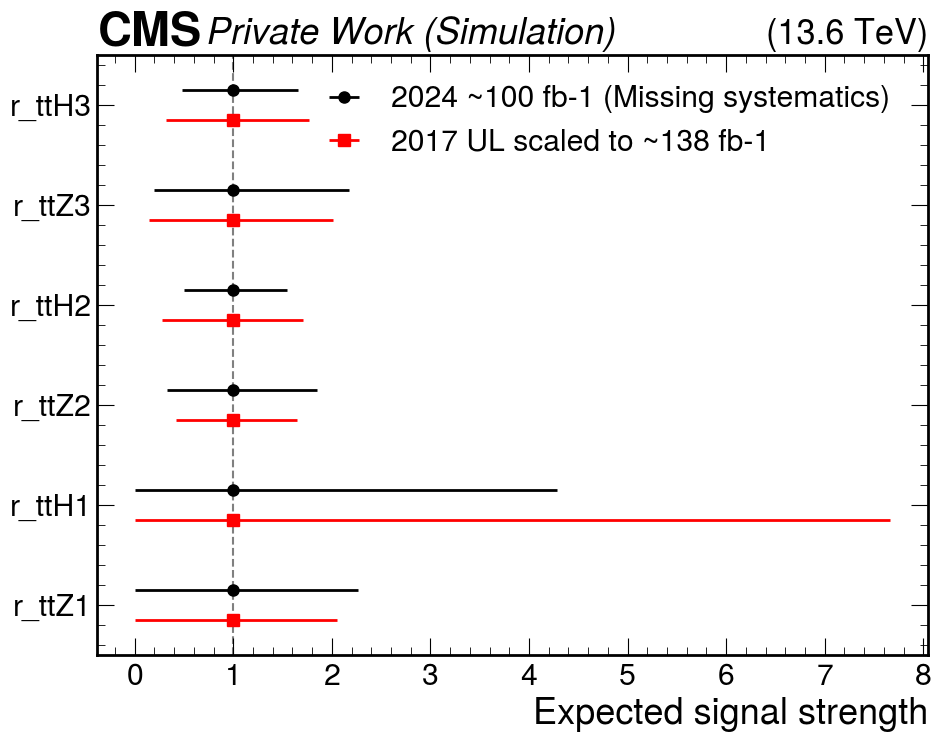

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep

# 1. Apply the official CMS style globally
hep.style.use(hep.style.CMS)

# Parameters and Data
params = ['r_ttZ1', 'r_ttH1', 'r_ttZ2', 'r_ttH2', 'r_ttZ3', 'r_ttH3']
y_pos = np.arange(len(params))

# Fit 1 (Initial Profile-Likelihood)
fit1_best = np.ones(6)
fit1_err_down = np.array([1.000, 1.000, 0.675, 0.495, 0.801, 0.516])
fit1_err_up = np.array([1.265, 3.285, 0.845, 0.546, 1.176, 0.654])

# Fit 2 (MultiDimFit)
fit2_best = np.ones(6)
fit2_err_down = np.array([1.000, 1.000, 0.577, 0.725, 0.855, 0.684])
fit2_err_up = np.array([1.048, 6.666, 0.643, 0.705, 1.016, 0.772])

fig, ax = plt.subplots(figsize=(10, 8))

# Offset for visual clarity so points don't overlap
offset = 0.15 

# Plot points with error bars
# mplhep defaults are quite good, but we keep some specific settings for the forest plot
ax.errorbar(fit1_best, y_pos + offset, xerr=[fit1_err_down, fit1_err_up], 
            fmt='o', color='black', capsize=0, elinewidth=2, markersize=8, label='2024 ~100 fb-1 (Missing systematics) ')
            
ax.errorbar(fit2_best, y_pos - offset, xerr=[fit2_err_down, fit2_err_up], 
            fmt='s', color='red', capsize=0, elinewidth=2, markersize=8, label='2017 UL scaled to ~138 fb-1')

# Reference line at best fit = 1
ax.axvline(1.0, color='gray', linestyle='--', zorder=0)

# Labels and ticks
ax.set_yticks(y_pos)
ax.set_yticklabels(params)
ax.set_xlabel('Expected signal strength')
ax.set_ylim(-0.5, len(params) - 0.5)

# 2. Add the official CMS header
# data=False writes "Simulation", label="Preliminary" writes "Simulation Preliminary"
# loc=0 places it above the plot (standard CMS format)
hep.cms.label(exp="CMS", label="Private Work (Simulation)", loc=0, ax=ax, data=True, rlabel='(13.6 TeV)')

# Add Legend
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig('cms_limits_mplhep.png', dpi=300)
plt.show()